In [12]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
IMAGE_PATH = "/content/drive/MyDrive/ATML/images"
DATA_PATH = "/content/drive/MyDrive/ATML/data"

In [9]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plot

from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification

In [14]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



Device: cuda
GPU: Tesla T4


In [15]:
#! Load the pretrained ViT
model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)

model = ViTForImageClassification.from_pretrained(model_name)

model = model.to(device)

model.eval()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

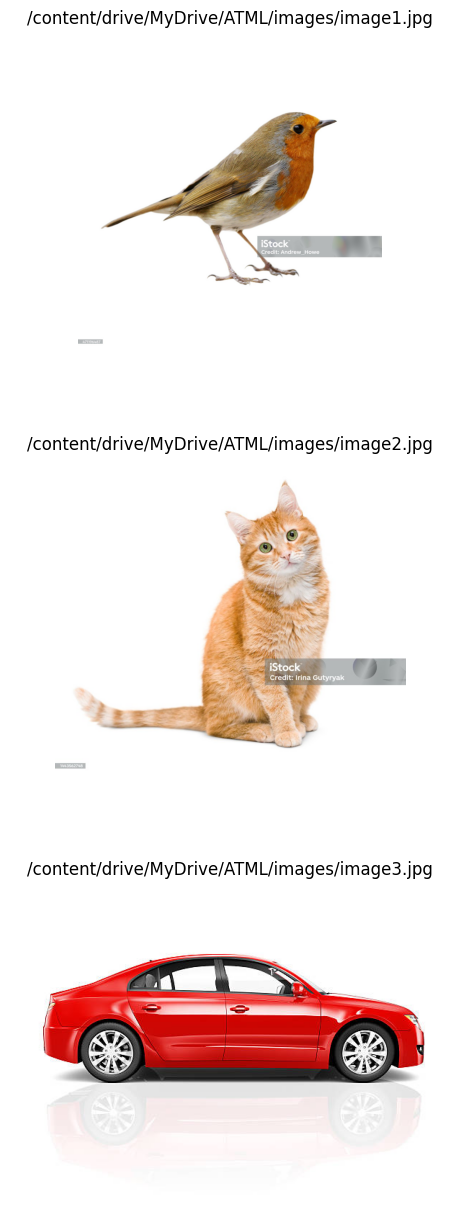

In [20]:
#! Loading the 3 images and displaying them
image_paths = [
                f"{IMAGE_PATH}/image1.jpg",
                f"{IMAGE_PATH}/image2.jpg",
                f"{IMAGE_PATH}/image3.jpg"
              ]

images = []

for path in image_paths:
    #! convert it so it can contain only 3 colors
    image = Image.open(path).convert("RGB")
    images.append(image)

fig, axes = plot.subplots(3, 1, figsize=(6, 15))

for i, image in enumerate(images):
    axes[i].imshow(image)
    axes[i].set_title(image_paths[i], pad=15)
    axes[i].axis("off")

plot.subplots_adjust(hspace=0.4)
plot.show()

In [21]:
#! Process 1 image and put into GPU
inputs = processor(images= images[0], return_tensors="pt")

print(inputs["pixel_values"].shape)

pixel_values = inputs["pixel_values"].to(device)
print(pixel_values.shape)
print(pixel_values.device)

#! Run the model with the pictures
with torch.no_grad():
    outputs = model(pixel_values)

print(outputs.logits.shape)

#! Predict the class for that image
predicted_class_index = outputs.logits.argmax(dim = 1).item()

predicted_class = model.config.id2label[predicted_class_index]

print("Predicted class index:", predicted_class_index)
print("Predicted class:", predicted_class)


torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
cuda:0
torch.Size([1, 1000])
Predicted class index: 10
Predicted class: brambling, Fringilla montifringilla


In [22]:
#! Predict all images
predictions = []

for image in images:
    inputs = processor(images = image, return_tensors= "pt")

    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        outputs = model(pixel_values)

    predicted_class_index = outputs.logits.argmax(dim = 1).item()
    predicted_class = model.config.id2label[predicted_class_index]

    predictions.append(predicted_class)

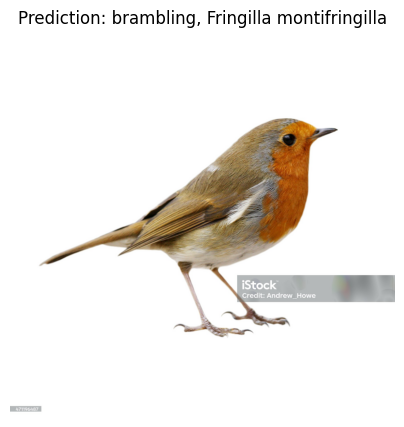

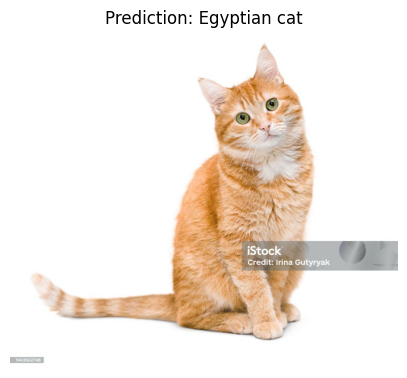

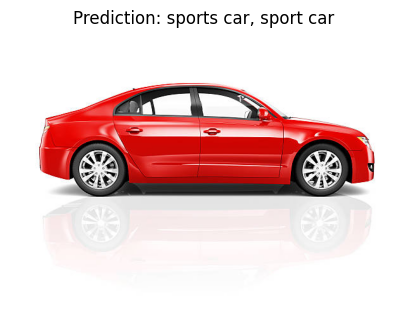

/content/drive/MyDrive/ATML/images/image1.jpg -> brambling, Fringilla montifringilla
/content/drive/MyDrive/ATML/images/image2.jpg -> Egyptian cat
/content/drive/MyDrive/ATML/images/image3.jpg -> sports car, sport car


In [23]:
#! Display Image with Predictions
for i, image in enumerate(images):
    plot.figure(figsize=(5,5))

    plot.imshow(image)
    plot.title(f"Prediction: {predictions[i]}")
    plot.axis("off")

    plot.show()

for path, prediction in zip(image_paths, predictions):
    print(f"{path} -> {prediction}")

In [24]:
#! Reload ViT so attention weights are available

model = ViTForImageClassification.from_pretrained(model_name, attn_implementation = "eager")

model = model.to(device)
model.eval()

#! Run 1 image and request attention

inputs = processor(images= images[0], return_tensors= "pt")

pixel_values = inputs["pixel_values"].to(device)

with torch.no_grad():
    outputs = model(pixel_values, output_attentions = True)

#! Inspect the attention output

attentions = outputs.attentions

print("Number of Transformer layers: ", len(attentions))

for i, attention in enumerate(attentions):
    print("Layer ", i + 1, ": ", attention.shape)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Number of Transformer layers:  12
Layer  1 :  torch.Size([1, 12, 197, 197])
Layer  2 :  torch.Size([1, 12, 197, 197])
Layer  3 :  torch.Size([1, 12, 197, 197])
Layer  4 :  torch.Size([1, 12, 197, 197])
Layer  5 :  torch.Size([1, 12, 197, 197])
Layer  6 :  torch.Size([1, 12, 197, 197])
Layer  7 :  torch.Size([1, 12, 197, 197])
Layer  8 :  torch.Size([1, 12, 197, 197])
Layer  9 :  torch.Size([1, 12, 197, 197])
Layer  10 :  torch.Size([1, 12, 197, 197])
Layer  11 :  torch.Size([1, 12, 197, 197])
Layer  12 :  torch.Size([1, 12, 197, 197])


In [25]:

#! Take the final Transformer layer

last_layer_attention = attentions[-1]
print(last_layer_attention.shape)

torch.Size([1, 12, 197, 197])


In [26]:

#! Average all attention heads

mean_attention = last_layer_attention.mean(dim = 1)
print(mean_attention.shape)

#! Extract CLS -> patch attention
cls_attention = mean_attention[0,0, 1:]
print(cls_attention.shape)

torch.Size([1, 197, 197])
torch.Size([196])


In [27]:
#! Reshape 196 patches back into the image grid
patch_size = model.config.patch_size
image_size = model.config.image_size

num_patches_per_side = image_size // patch_size

attention_grid = cls_attention.reshape(num_patches_per_side, num_patches_per_side)

print("Patch size:", patch_size)

Patch size: 16


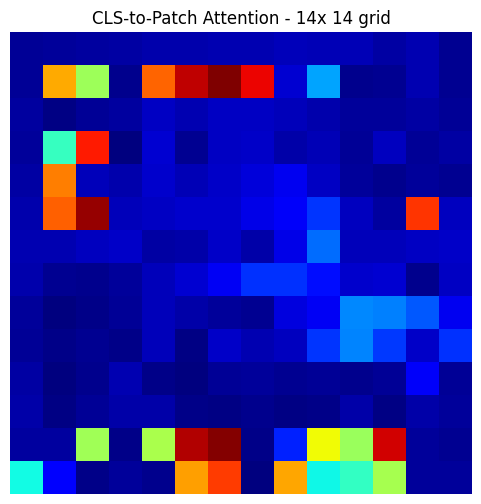

In [28]:
plot.figure(figsize= (6,6))

plot.imshow(attention_grid.detach().cpu().numpy(), cmap = "jet")
plot.title("CLS-to-Patch Attention - 14x 14 grid")
plot.axis("off")

plot.show()

In [29]:
import torch.nn.functional as F

original_width, original_height = images[0].size

attention_map = attention_grid.unsqueeze(0).unsqueeze(0)

attention_map = F.interpolate(
                                attention_map,
                                size = (original_height, original_width),
                                mode = "bilinear",
                                align_corners= False
                             )

attention_map = attention_map.squeeze()
attention_map = attention_map.detach().cpu().numpy()

print(attention_map.shape)

(2000, 2000)


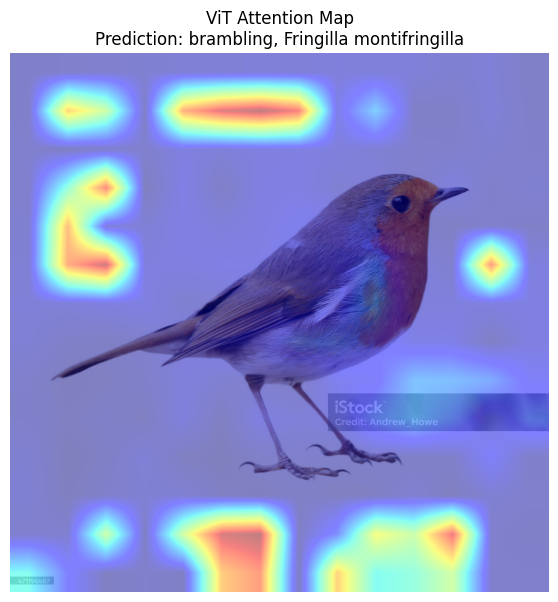

In [30]:
#! Normalize and plot
attention_map  = (attention_map - attention_map.min() ) / (attention_map.max() - attention_map.min())

plot.figure(figsize= (7,7))

plot.imshow(images[0])
plot.imshow(attention_map, cmap = "jet", alpha= 0.5)
plot.title(f"ViT Attention Map\nPrediction: {predictions[0]}")
plot.axis("off")

plot.show()

## 2.3 Attention Analysis

In [32]:
def get_head_attention_maps(image):
    inputs = processor(images= image, return_tensors= "pt")

    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        outputs = model(pixel_values, output_attentions = True)

    last_layer_attention = outputs.attentions[-1][0]
    cls_attention = last_layer_attention[:, 0, 1:]
    num_heads = cls_attention.shape[0]
    grid_size = int(cls_attention.shape[-1] ** 0.5)

    head_attention_maps = cls_attention.reshape(num_heads, grid_size, grid_size)

    return head_attention_maps.detach().cpu().numpy()

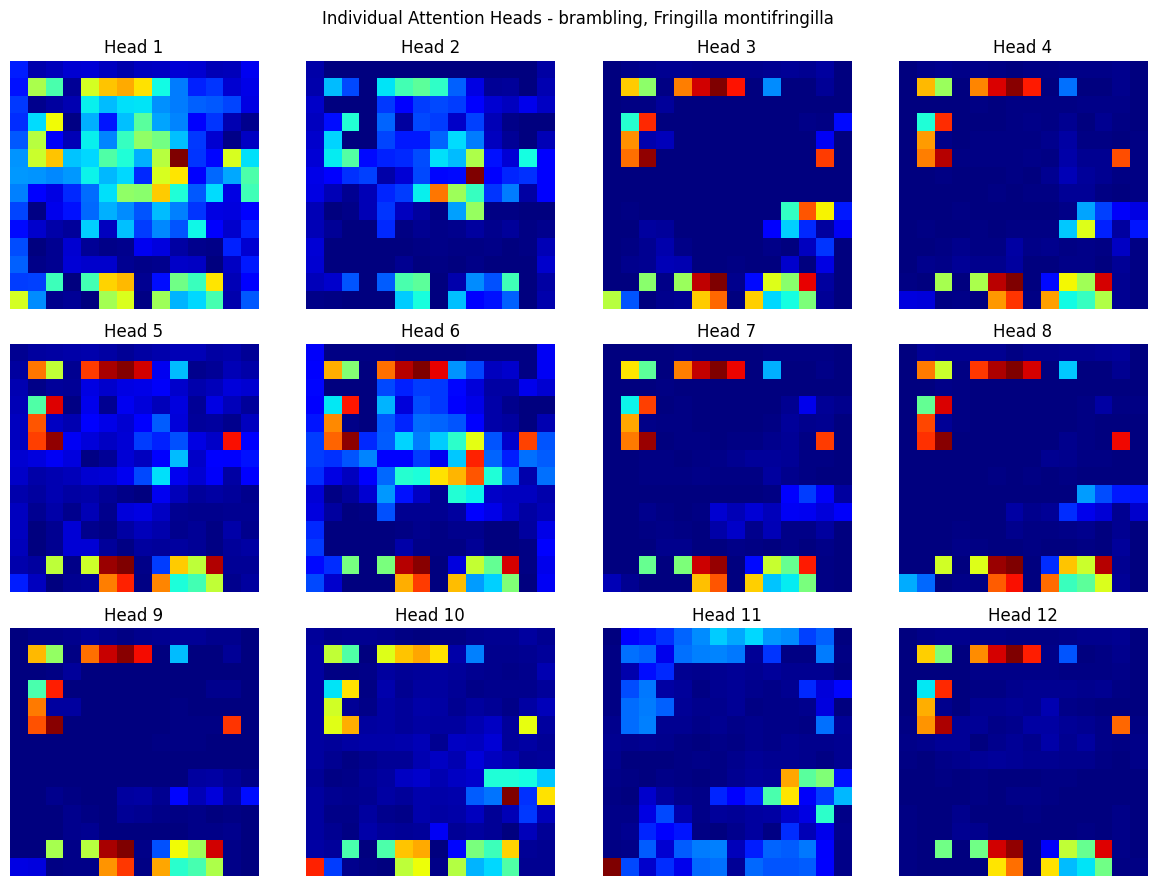

In [33]:
head_attention_maps = get_head_attention_maps(images[0])
num_heads = head_attention_maps.shape[0]

figure, axes = plot.subplots(3, 4, figsize= (12,9))

for head_index, axis in enumerate(axes.flat):
    axis.imshow(head_attention_maps[head_index], cmap="jet")
    axis.set_title(f"Head {head_index + 1}")
    axis.axis("off")

plot.suptitle(f"Individual Attention Heads - {predictions[0]}")
plot.tight_layout()

plot.show()

In [34]:
inputs = processor(images= images[0], return_tensors= "pt")

pixel_values = inputs["pixel_values"].to(device)

with torch.no_grad():
    outputs = model(pixel_values, output_attentions = True)

last_layer_attention = outputs.attentions[-1][0]

cls_attention = last_layer_attention[:, 0, 1:]

normalized_attention = (cls_attention / cls_attention.sum(dim = 1, keepdim = True))

entropy = -(normalized_attention * torch.log(normalized_attention + 1e-12)).sum(dim = 1)

maximum_attention = normalized_attention.max(dim = 1).values

for head_index in range(cls_attention.shape[0]):
    print(
           f"Head {head_index + 1}: "
           f"Entropy = {entropy[head_index].item():.4f}, "
           f"Max Attention = {maximum_attention[head_index].item():.4f}"
         )

Head 1: Entropy = 4.9383, Max Attention = 0.0213
Head 2: Entropy = 4.5336, Max Attention = 0.0438
Head 3: Entropy = 3.7423, Max Attention = 0.0428
Head 4: Entropy = 3.7871, Max Attention = 0.0450
Head 5: Entropy = 4.4333, Max Attention = 0.0334
Head 6: Entropy = 4.5544, Max Attention = 0.0264
Head 7: Entropy = 3.6907, Max Attention = 0.0493
Head 8: Entropy = 3.6456, Max Attention = 0.0442
Head 9: Entropy = 3.5569, Max Attention = 0.0486
Head 10: Entropy = 4.3382, Max Attention = 0.0409
Head 11: Entropy = 4.5616, Max Attention = 0.0504
Head 12: Entropy = 3.5908, Max Attention = 0.0525


### Individual Attention Head Analysis

### Comparison with Grad-CAM


## 2.4 Patch-Masking Experiment

In [35]:
def predict_from_pixel_values(pixel_values):
    with torch.no_grad():
        outputs = model(pixel_values)

    probabilities = torch.softmax(outputs.logits, dim = 1)

    predicted_index = probabilities.argmax(dim = 1).item()
    predicted_label = model.config.id2label[predicted_index]

    predicted_confidence = probabilities[0, predicted_index].item()

    return predicted_index, predicted_label, predicted_confidence, probabilities


In [36]:
inputs = processor(images= images[0], return_tensors= "pt")

original_pixel_values = inputs["pixel_values"].to(device)

print(original_pixel_values.shape)

(original_class_index, original_class_label, original_confidence, original_probabilities) = predict_from_pixel_values(original_pixel_values)

print("Orignal prediction:", original_class_label)
print(
        "Original confidence:",
        f"{original_confidence * 100:.2f}%"
     )

torch.Size([1, 3, 224, 224])
Orignal prediction: brambling, Fringilla montifringilla
Original confidence: 81.88%


In [37]:
def random_patch_mask(pixel_values, mask_ratio, patch_size = 16):
    masked_values = pixel_values.clone()
    height = masked_values.shape[2]
    width = masked_values.shape[3]

    patches_y = height // patch_size
    patches_x = width // patch_size

    total_patches = patches_y * patches_x

    number_to_mask = int(total_patches * mask_ratio)

    random_indices = torch.randperm(total_patches)[:number_to_mask]

    for index in random_indices:
        index = index.item()

        row = index // patches_x
        column = index % patches_x

        y_start = row * patch_size
        y_end = y_start + patch_size

        x_start = column * patch_size
        x_end = x_start + patch_size

        masked_values[:, :, y_start:y_end, x_start:x_end] = 0

    return masked_values

In [38]:
mask_ratios = [0.25, 0.50, 0.75]

random_mask_results = []

for mask_ratio in mask_ratios:
    masked_values = random_patch_mask(original_pixel_values, mask_ratio)

    (predicted_index, predicted_label, predicted_confidence, probabilities) = predict_from_pixel_values(masked_values)

    original_class_confidence = probabilities[0, original_class_index].item()

    random_mask_results.append({
                                "mask_ratio": mask_ratio,
                                "prediction": predicted_label,
                                "top_confidence": predicted_confidence,
                                "original_class_confidence": original_class_confidence
                               })

In [39]:
print("Original:", original_class_label,  f"({original_confidence* 100:.2f}%)")

print()

for result in random_mask_results:
    print(f"Random Mask {result['mask_ratio'] * 100:.0f}%")

    print("Prediction:", result["prediction"])

    print("Top Confidence:", f"{result['top_confidence'] * 100:.2f}%")

    print(
        "Original-Class Confidence:", f"{result['original_class_confidence'] * 100:.2f}%")

    print()


Original: brambling, Fringilla montifringilla (81.88%)

Random Mask 25%
Prediction: brambling, Fringilla montifringilla
Top Confidence: 73.26%
Original-Class Confidence: 73.26%

Random Mask 50%
Prediction: brambling, Fringilla montifringilla
Top Confidence: 53.61%
Original-Class Confidence: 53.61%

Random Mask 75%
Prediction: bulbul
Top Confidence: 22.06%
Original-Class Confidence: 20.89%



In [40]:
def center_patch_mask(pixel_values, mask_ratio, patch_size = 16):
    masked_values = pixel_values.clone()

    height = masked_values.shape[2]
    width = masked_values.shape[3]

    patches_y = height // patch_size
    patches_x = width // patch_size

    total_patches = patches_y * patches_x

    number_to_mask = int(total_patches * mask_ratio)

    center_y = (patches_y - 1) / 2
    center_x = (patches_x - 1) / 2

    patch_distances = []

    for row in range(patches_y):
        for column in range(patches_x):
            distance = (row - center_y) ** 2 + (column - center_x) ** 2
            patch_distances.append((distance, row, column))

    patch_distances.sort(key = lambda x: x[0])

    patches_to_mask = patch_distances[:number_to_mask]

    for _, row, column in patches_to_mask:

        y_start = row * patch_size
        y_end = y_start + patch_size

        x_start = column * patch_size
        x_end = x_start + patch_size

        masked_values[:, :, y_start:y_end, x_start:x_end] = 0

    return masked_values

In [41]:
center_mask_results = []

for mask_ratio in mask_ratios:
    masked_values = center_patch_mask(original_pixel_values, mask_ratio)

    (predicted_index, predicted_label, predicted_confidence, probabilities) = predict_from_pixel_values(masked_values)

    original_class_confidence = probabilities[0, original_class_index].item()

    center_mask_results.append({
                                "mask_ratio": mask_ratio,
                                "prediction": predicted_label,
                                "top_confidence": predicted_confidence,
                                "original_class_confidence": original_class_confidence
                              })

In [42]:
for result in center_mask_results:
    print(f"Center Mask {result['mask_ratio'] * 100:.0f}%")

    print("Prediction:", result["prediction"])

    print("Top Confidence:", f"{result['top_confidence'] * 100:.2f}%")

    print("Original-Class Confidence:", f"{result['original_class_confidence'] * 100:.2f}%")

    print()

Center Mask 25%
Prediction: brambling, Fringilla montifringilla
Top Confidence: 16.96%
Original-Class Confidence: 16.96%

Center Mask 50%
Prediction: screw
Top Confidence: 18.71%
Original-Class Confidence: 0.01%

Center Mask 75%
Prediction: beaker
Top Confidence: 2.66%
Original-Class Confidence: 0.02%



In [43]:
def pixel_values_to_image(pixel_values):
    image_tensor = (pixel_values[0]).detach().cpu().clone()

    mean = torch.tensor(processor.image_mean).view(3,1,1)

    std = torch.tensor(processor.image_std).view(3,1,1)

    image_tensor = (image_tensor * std + mean)
    image_tensor = image_tensor.clamp(0,1)
    image_array = image_tensor.permute(1,2,0).numpy()

    return image_array


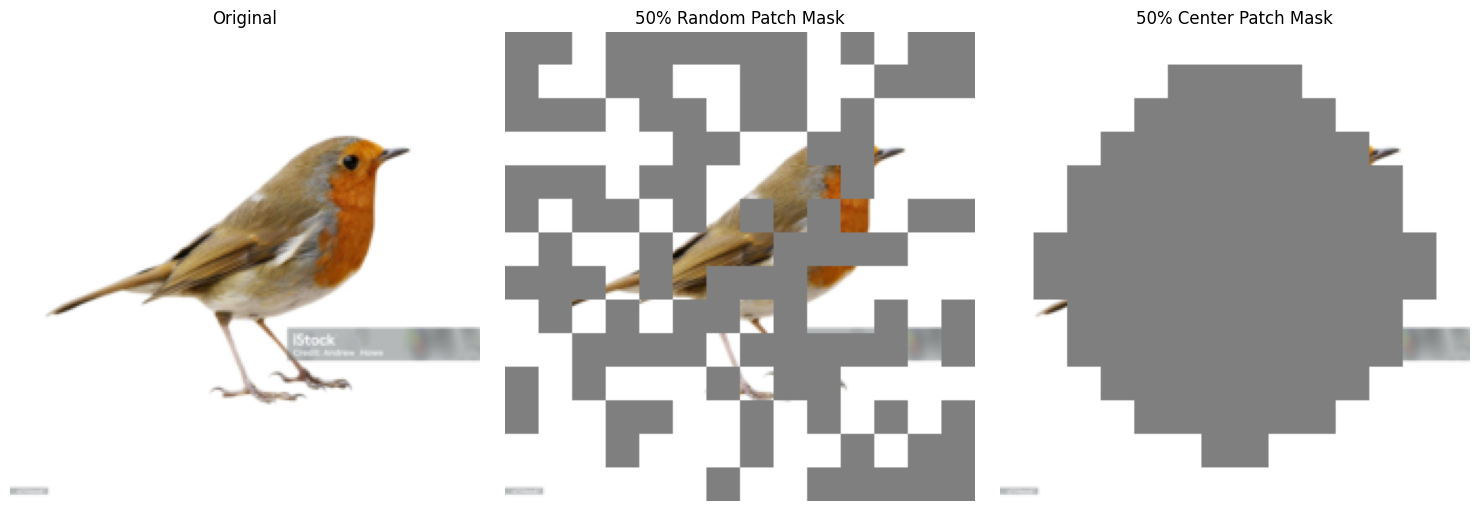

In [44]:
random_50 = random_patch_mask(original_pixel_values, 0.50)

center_50 = center_patch_mask(original_pixel_values, 0.50)

fig, axes = plot.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(pixel_values_to_image(original_pixel_values))
axes[0].set_title("Original")
axes[0].axis("off")


axes[1].imshow(pixel_values_to_image(random_50))
axes[1].set_title("50% Random Patch Mask")
axes[1].axis("off")


axes[2].imshow(pixel_values_to_image(center_50))
axes[2].set_title("50% Center Patch Mask")
axes[2].axis("off")

plot.tight_layout()
plot.show()

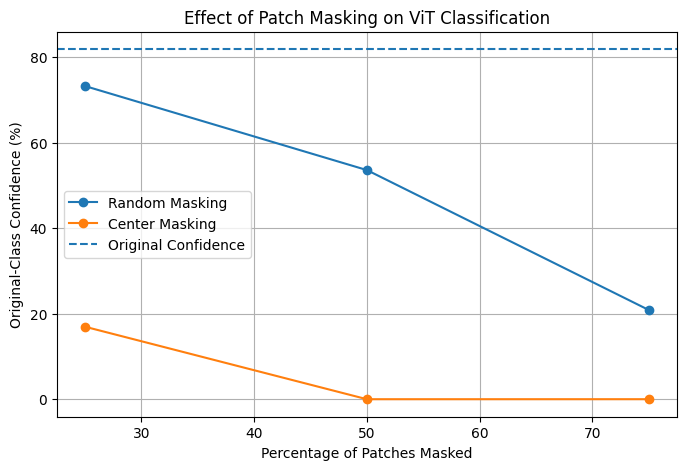

In [ ]:
random_confidences = [result["original_class_confidence"] * 100 for result in random_mask_results]

center_confidences = [result["original_class_confidence"] * 100 for result in center_mask_results]

mask_percentages = [ratio * 100 for ratio in mask_ratios]

plot.figure(figsize=(8, 5))

plot.plot(mask_percentages, random_confidences, marker="o", label="Random Masking")

plot.plot(mask_percentages, center_confidences, marker="o", label="Center Masking")

plot.axhline(y=original_confidence * 100, linestyle="--", label="Original Confidence")

plot.xlabel("Percentage of Patches Masked")
plot.ylabel("Original-Class Confidence (%)")

plot.title("Effect of Patch Masking on Original-Class Confidence")

plot.legend()

plot.grid()

plot.show()

### Patch-Masking Analysis



## 2.5 CLS Token vs Mean-Pooled Patch Tokens

In [46]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

In [47]:
vit_transform = transforms.Compose([
                                     transforms.Resize((model.config.image_size, model.config.image_size)),
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean = processor.image_mean, std = processor.image_std)
                                    ])

In [49]:
train_dataset = datasets.CIFAR10(
    root= DATA_PATH,
    train=True,
    download=True,
    transform=vit_transform
)

test_dataset = datasets.CIFAR10(
    root= DATA_PATH,
    train=False,
    download=True,
    transform=vit_transform
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

Training images: 50000
Test images: 10000


In [50]:
FEATURE_BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=FEATURE_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=FEATURE_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [51]:
for parameter in model.parameters():
    parameter.requires_grad = False

model.eval()

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [52]:
def extract_features(data_loader):
    cls_features_list = []
    mean_features_list = []
    labels_list = []

    with torch.no_grad():

        for images_batch, labels_batch in data_loader:

            images_batch = images_batch.to(device)

            outputs = model.vit(pixel_values=images_batch)

            hidden_states = outputs.last_hidden_state

            cls_features = hidden_states[:, 0, :]

            patch_features = hidden_states[:, 1:, :]

            mean_features = patch_features.mean(dim=1)

            cls_features_list.append(cls_features.cpu())

            mean_features_list.append(mean_features.cpu())

            labels_list.append(labels_batch.cpu())

    cls_features = torch.cat(cls_features_list,dim=0)
    mean_features = torch.cat(mean_features_list, dim=0)
    labels = torch.cat(labels_list, dim=0)

    return cls_features, mean_features, labels

In [53]:
train_cls_features, train_mean_features, train_labels = (extract_features(train_loader))

print("CLS training features:", train_cls_features.shape)
print("Mean training features:", train_mean_features.shape)
print("Training labels:",train_labels.shape)

CLS training features: torch.Size([50000, 768])
Mean training features: torch.Size([50000, 768])
Training labels: torch.Size([50000])


In [54]:
test_cls_features, test_mean_features, test_labels = (extract_features(test_loader))

print("CLS test features:", test_cls_features.shape)
print("Mean test features:", test_mean_features.shape)
print("Test labels:", test_labels.shape)

CLS test features: torch.Size([10000, 768])
Mean test features: torch.Size([10000, 768])
Test labels: torch.Size([10000])


In [55]:
torch.save(
    {
        "train_cls": train_cls_features,
        "train_mean": train_mean_features,
        "train_labels": train_labels,
        "test_cls": test_cls_features,
        "test_mean": test_mean_features,
        "test_labels": test_labels
    },
    "vit_cifar10_features.pt"
)

In [56]:
cls_train_dataset = TensorDataset(train_cls_features, train_labels)

cls_test_dataset = TensorDataset(test_cls_features, test_labels)

mean_train_dataset = TensorDataset(train_mean_features, train_labels)

mean_test_dataset = TensorDataset(test_mean_features, test_labels)

In [57]:
PROBE_BATCH_SIZE = 256

cls_train_loader = DataLoader(cls_train_dataset, batch_size=PROBE_BATCH_SIZE, shuffle=True)

cls_test_loader = DataLoader(cls_test_dataset, batch_size=PROBE_BATCH_SIZE, shuffle=False)

mean_train_loader = DataLoader(mean_train_dataset, batch_size=PROBE_BATCH_SIZE, shuffle=True)

mean_test_loader = DataLoader(mean_test_dataset, batch_size=PROBE_BATCH_SIZE, shuffle=False)

In [58]:
class LinearProbe(nn.Module):

    def __init__(self, input_dimension, number_of_classes):
        super().__init__()

        self.classifier = nn.Linear(input_dimension, number_of_classes)

    def forward(self, features):
        return self.classifier(features)

In [59]:
def train_linear_probe(model_probe, train_loader, epochs, learning_rate):
    model_probe = model_probe.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model_probe.parameters(), lr=learning_rate)

    training_losses = []
    training_accuracies = []

    for epoch in range(epochs):
        model_probe.train()

        running_loss = 0.0
        correct_predictions = 0
        total_predictions = 0

        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model_probe(features)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            running_loss += (loss.item() * features.size(0))
            predictions = outputs.argmax(dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_predictions += labels.size(0)

        epoch_loss = (running_loss / total_predictions)

        epoch_accuracy = (100 * correct_predictions / total_predictions)

        training_losses.append(epoch_loss)

        training_accuracies.append(epoch_accuracy)

        print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Loss: {epoch_loss:.4f} | "
                f"Accuracy: {epoch_accuracy:.2f}%"
             )

    return (model_probe, training_losses, training_accuracies)

In [60]:
def evaluate_linear_probe(model_probe, test_loader):
    model_probe.eval()

    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():

        for features, labels in test_loader:

            features = features.to(device)
            labels = labels.to(device)

            outputs = model_probe(features)

            predictions = outputs.argmax(dim=1)

            correct_predictions += (predictions == labels).sum().item()

            total_predictions += labels.size(0)

    accuracy = (100 * correct_predictions / total_predictions)

    return accuracy

In [61]:
PROBE_EPOCHS = 10
PROBE_LEARNING_RATE = 0.001

INPUT_DIMENSION = model.config.hidden_size
NUMBER_OF_CLASSES = 10

print(
    "Feature dimension:",
    INPUT_DIMENSION
)

Feature dimension: 768


In [62]:
torch.manual_seed(SEED)

cls_probe = LinearProbe(INPUT_DIMENSION, NUMBER_OF_CLASSES)

(cls_probe, cls_losses, cls_accuracies) = train_linear_probe(cls_probe, cls_train_loader, PROBE_EPOCHS, PROBE_LEARNING_RATE)

Epoch 1/10 | Loss: 0.2319 | Accuracy: 94.11%
Epoch 2/10 | Loss: 0.1000 | Accuracy: 96.93%
Epoch 3/10 | Loss: 0.0865 | Accuracy: 97.33%
Epoch 4/10 | Loss: 0.0777 | Accuracy: 97.55%
Epoch 5/10 | Loss: 0.0717 | Accuracy: 97.73%
Epoch 6/10 | Loss: 0.0664 | Accuracy: 97.92%
Epoch 7/10 | Loss: 0.0623 | Accuracy: 98.02%
Epoch 8/10 | Loss: 0.0591 | Accuracy: 98.17%
Epoch 9/10 | Loss: 0.0564 | Accuracy: 98.25%
Epoch 10/10 | Loss: 0.0539 | Accuracy: 98.33%


In [63]:
cls_test_accuracy = evaluate_linear_probe(cls_probe, cls_test_loader)

print(
        f"CLS Test Accuracy: "
        f"{cls_test_accuracy:.2f}%"
     )

CLS Test Accuracy: 96.99%


In [64]:
torch.manual_seed(SEED)

mean_probe = LinearProbe(INPUT_DIMENSION, NUMBER_OF_CLASSES)

(mean_probe, mean_losses, mean_accuracies) = train_linear_probe(mean_probe, mean_train_loader, PROBE_EPOCHS,PROBE_LEARNING_RATE)

Epoch 1/10 | Loss: 0.2672 | Accuracy: 94.29%
Epoch 2/10 | Loss: 0.1012 | Accuracy: 97.05%
Epoch 3/10 | Loss: 0.0858 | Accuracy: 97.46%
Epoch 4/10 | Loss: 0.0769 | Accuracy: 97.66%
Epoch 5/10 | Loss: 0.0705 | Accuracy: 97.88%
Epoch 6/10 | Loss: 0.0657 | Accuracy: 97.98%
Epoch 7/10 | Loss: 0.0614 | Accuracy: 98.14%
Epoch 8/10 | Loss: 0.0583 | Accuracy: 98.20%
Epoch 9/10 | Loss: 0.0553 | Accuracy: 98.27%
Epoch 10/10 | Loss: 0.0528 | Accuracy: 98.38%


In [65]:
mean_test_accuracy = evaluate_linear_probe(mean_probe, mean_test_loader)

print(f"Mean-Pooling Test Accuracy: " f"{mean_test_accuracy:.2f}%")

Mean-Pooling Test Accuracy: 97.24%


In [66]:
print("Linear Probe Comparison")
print("-----------------------")

print(f"CLS Token Accuracy: " f"{cls_test_accuracy:.2f}%")

print(f"Mean-Pooling Accuracy: " f"{mean_test_accuracy:.2f}%")

difference = (cls_test_accuracy - mean_test_accuracy)

print(f"Difference: " f"{difference:.2f} percentage points")

Linear Probe Comparison
-----------------------
CLS Token Accuracy: 96.99%
Mean-Pooling Accuracy: 97.24%
Difference: -0.25 percentage points


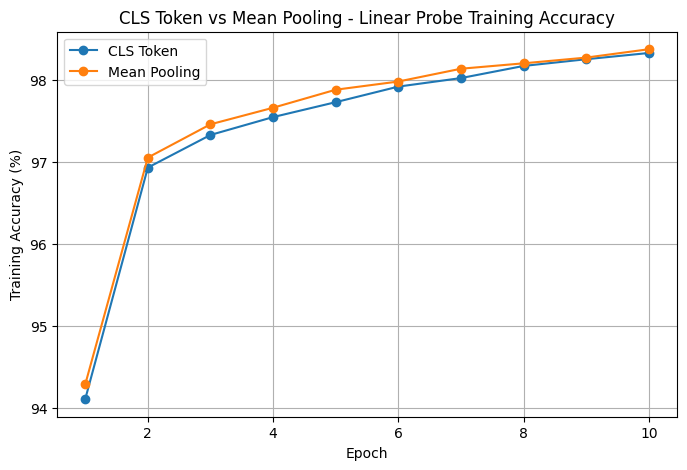

In [67]:
epochs = range(1, PROBE_EPOCHS + 1)

plot.figure(figsize=(8, 5))

plot.plot(epochs, cls_accuracies, marker="o", label="CLS Token")

plot.plot(epochs, mean_accuracies, marker="o", label="Mean Pooling")

plot.xlabel("Epoch")
plot.ylabel("Training Accuracy (%)")
plot.title( "CLS Token vs Mean Pooling - " "Linear Probe Training Accuracy")
plot.legend()
plot.grid()

plot.show()

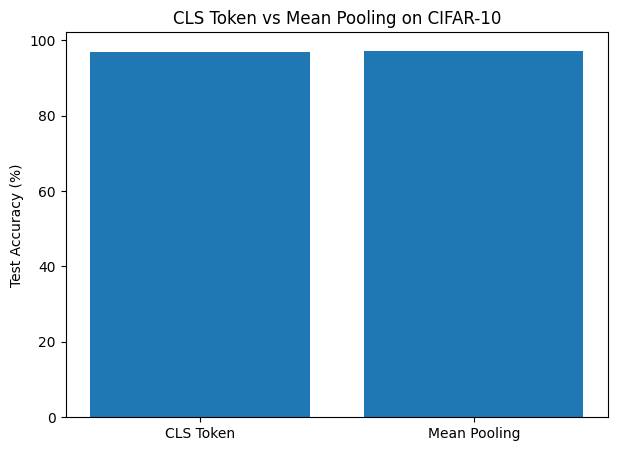

In [68]:
methods = ["CLS Token", "Mean Pooling" ]

accuracies = [cls_test_accuracy, mean_test_accuracy]

plot.figure(figsize=(7, 5))

plot.bar(methods, accuracies)
plot.ylabel("Test Accuracy (%)")
plot.title( "CLS Token vs Mean Pooling " "on CIFAR-10")

plot.show()